In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, zscore
from scipy.special import logit, expit
from statsmodels.stats.multitest import multipletests
from ALLCools.mcds import MCDS 

# Define paths
mcds_path = '/ceph/MethDev/pbio/hazel/gene_mcds/gene'
rna_path = '/ceph/MethDev/pbio/hazel/count_Arab13_with_TEs.csv'
meta_path = '/ceph/MethDev/pbio/hazel/merged_cluster_assignments.csv'

# Load datasets
mcds = MCDS.open(mcds_paths=mcds_path, var_dim='gene')
rna = pd.read_csv(rna_path).T
meta = pd.read_csv(meta_path).set_index('cell_id')

print(f"Loaded RNA shape: {rna.shape}")
print(f"Loaded Meta shape: {meta.shape}")

Loaded RNA shape: (6071, 64507)
Loaded Meta shape: (5908, 1)


In [2]:
# Align cells
common_cells = rna.index.intersection(meta.index)
rna_aligned = rna.loc[common_cells]

# Normalize to CPM
cell_totals = rna_aligned.sum(axis=1)
rna_cpm = rna_aligned.div(cell_totals, axis=0) * 1e6

# Log1p transformation
rna_log1p = np.log1p(rna_cpm)

# Aggregate by cluster
rna_log1p['cluster'] = meta.loc[common_cells, 'merged_cluster']
cluster_rna_matrix = rna_log1p.groupby('cluster').mean().T

print(f"Processed RNA matrix shape: {cluster_rna_matrix.shape}")

Processed RNA matrix shape: (64507, 17)


In [3]:
# Get raw counts (c = methylated, m = total coverage)
mCGN_mc = mcds.sel(mc_type='CGN', count_type='mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(mc_type='CGN', count_type='cov').gene_da.to_pandas()

mCGN_mc['cluster'] = meta['merged_cluster']
mCGN_cov['cluster'] = meta['merged_cluster']

# Aggregate counts by cluster
cluster_c = mCGN_mc.groupby('cluster').sum().T  # Shape: (genes, clusters)
cluster_m = mCGN_cov.groupby('cluster').sum().T

# --- 1. Fit Global Offsets (deltas) ---
# Aggregate across all genes per cluster
global_c = cluster_c.sum(axis=0)
global_m = cluster_m.sum(axis=0)
global_p = global_c / global_m

d = logit(np.clip(global_p, 1e-6, 1-1e-6))
deltas = d - np.average(d, weights=global_m)

# --- 2. Calculate Expected Methylation (p0) ---
# Gene-wise baseline (pbar)
gene_c = cluster_c.sum(axis=1)
gene_m = cluster_m.sum(axis=1)

# Mask genes with extremely low total coverage to avoid noise
valid_genes_mask = gene_m >= 50 
cluster_c = cluster_c[valid_genes_mask]
cluster_m = cluster_m[valid_genes_mask]
gene_c = gene_c[valid_genes_mask]
gene_m = gene_m[valid_genes_mask]

pbar = np.clip(gene_c / gene_m, 1e-6, 1-1e-6)

# Broadcast expected values: p0 = expit(logit(pbar) + deltas)
# pbar is (genes,), deltas is (clusters,). We create a (genes, clusters) matrix
logit_pbar = logit(pbar).values[:, None]
expected_logit = logit_pbar + deltas.values[None, :]
p0_df = pd.DataFrame(expit(expected_logit), index=cluster_c.index, columns=cluster_c.columns)

# --- 3. Extract Adjusted Matrix ---
# Observed fractions
obs_p = cluster_c / cluster_m.replace(0, np.nan)
obs_p = obs_p.fillna(0) 

# Residuals: observed deviation from the cluster's global logit expectation
adj_meth_matrix = obs_p - p0_df

# Filter for genes that actually have meaningful methylation in at least one cluster
highly_meth_genes = obs_p[obs_p.apply(lambda x: (x >= 0.1).any(), axis=1)].index
filtered_meth_df = adj_meth_matrix.loc[highly_meth_genes]

print(f"Logit-adjusted Methylation matrix shape: {filtered_meth_df.shape}")

Logit-adjusted Methylation matrix shape: (13764, 17)


In [6]:
gene_c

gene
AT1G01010     1792
AT1G01020     1316
AT1G03987       14
AT1G01030      424
AT1G01040    89843
             ...  
ATCG01230        0
ATCG01240        0
ATCG01250        2
ATCG01280        9
ATCG01310        0
Length: 32357, dtype: int64

In [8]:
logit_pbar

array([[ -3.50543003],
       [ -2.93701266],
       [ -4.35027794],
       ...,
       [ -3.94158181],
       [ -4.15714546],
       [-13.81550956]])

In [10]:
deltas

cluster
0.0    -0.030475
1.0     0.074022
2.0     0.063551
3.0    -0.071465
4.0     0.075019
5.0     0.027629
6.0    -0.002777
7.0     0.163145
8.0    -0.277243
9.0    -0.133926
10.0   -0.320788
11.0    0.054085
12.0   -0.019998
13.0    0.040379
14.0    0.150963
15.0    0.100961
16.0   -0.078550
dtype: float64

In [11]:
# Align genes across both modalities
common_genes = cluster_rna_matrix.index.intersection(filtered_meth_df.index)
final_rna_df = cluster_rna_matrix.loc[common_genes]
final_meth_df = filtered_meth_df.loc[common_genes]

correlations = []
p_values = []
valid_genes = []

for gene in common_genes:
    rna_vals = final_rna_df.loc[gene].values
    meth_vals = final_meth_df.loc[gene].values # These are now the (obs - p0) residuals
    
    # Skip genes with zero variance
    if np.std(rna_vals) == 0 or np.std(meth_vals) == 0:
        continue
        
    rho, p = spearmanr(rna_vals, meth_vals)
    valid_genes.append(gene)
    correlations.append(rho)
    p_values.append(p)

# Compile statistical results
stats_df = pd.DataFrame({
    'gene': valid_genes,
    'rho': correlations,
    'p_value': p_values
}).set_index('gene')

# Apply FDR correction
stats_df['fdr'] = multipletests(stats_df['p_value'], method='fdr_bh')[1]

print("Top 20 negatively correlated genes (Logit Expected Corrected):")
print(stats_df.sort_values('rho').head(20))

Top 20 negatively correlated genes (Logit Expected Corrected):
                rho       p_value       fdr
gene                                       
AT4G01130 -0.904180  6.362151e-07  0.008107
AT4G30400 -0.875000  4.280116e-06  0.027269
AT4G05025 -0.857496  1.084623e-05  0.042392
AT3G26290 -0.843137  2.132810e-05  0.042392
AT5G46295 -0.842754  2.169619e-05  0.042392
AT2G03770 -0.841256  2.318915e-05  0.042392
AT2G34430 -0.833333  3.261049e-05  0.042392
AT5G08225 -0.828848  3.925220e-05  0.042392
AT3G62930 -0.828622  3.961423e-05  0.042392
AT1G55370 -0.828431  3.992311e-05  0.042392
AT3G19350 -0.824243  4.722537e-05  0.046288
AT1G62030 -0.817903  6.040722e-05  0.054979
AT2G07681 -0.806867  9.075647e-05  0.066583
AT2G20760 -0.806373  9.237188e-05  0.066583
AT5G40840 -0.803922  1.007394e-04  0.066583
AT4G17090 -0.801471  1.097353e-04  0.066583
AT2G07698 -0.801471  1.097353e-04  0.066583
AT5G46040 -0.787299  1.760714e-04  0.097544
AT5G04870 -0.784314  1.936516e-04  0.098956
AT5G26580 -0.

In [13]:
stats_df.loc["AT2G10940"]

rho       -0.602941
p_value    0.010407
fdr        0.405518
Name: AT2G10940, dtype: float64

# Data Exploration

Found 11 significantly correlated genes.


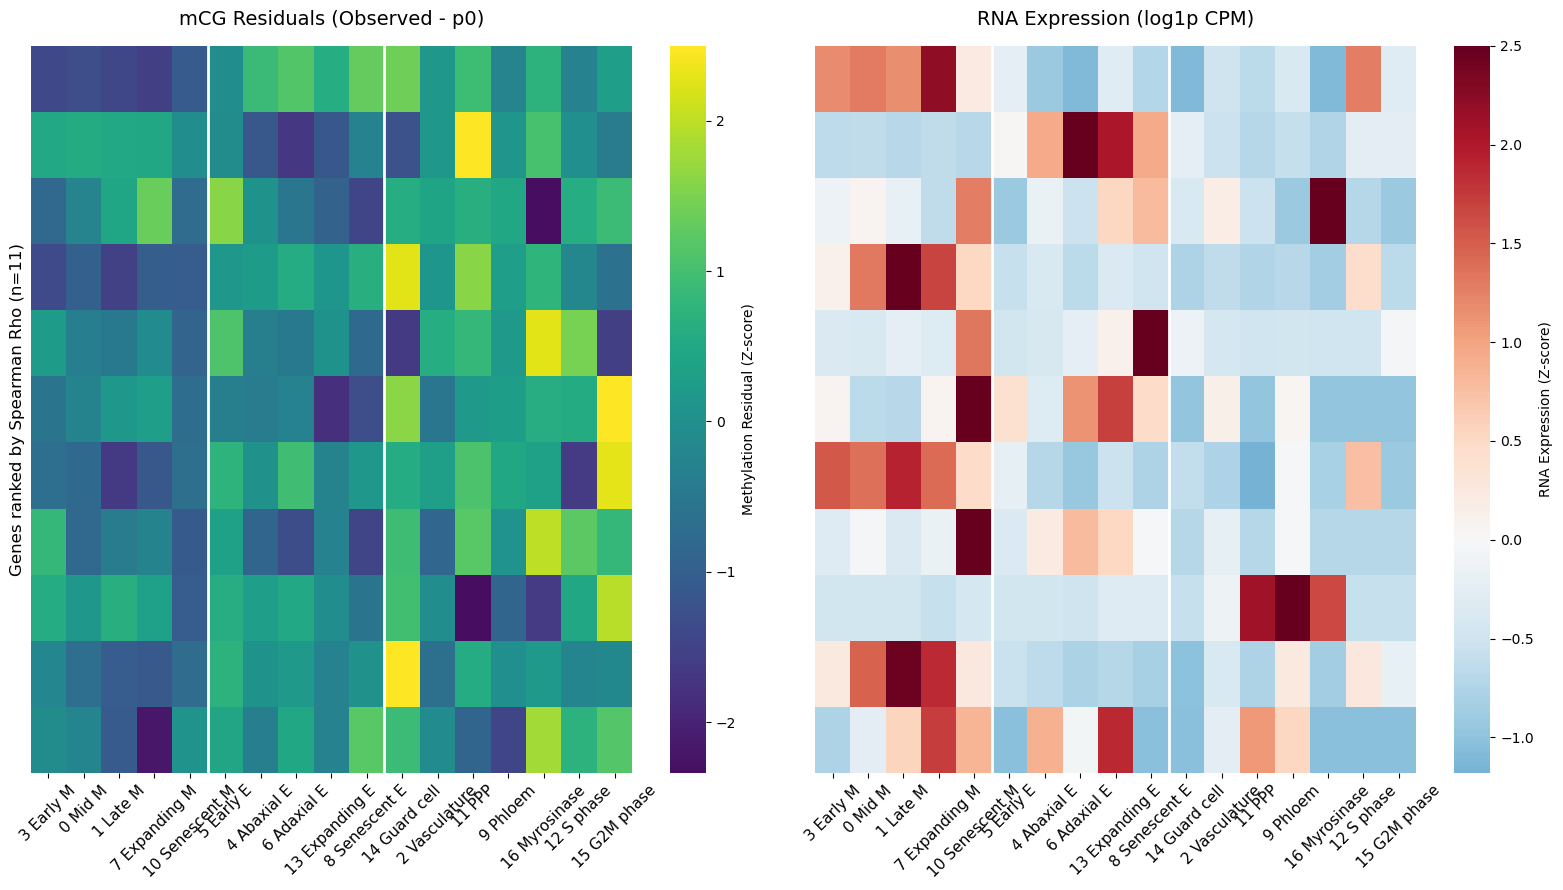

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import pandas as pd

# 1. Define the mapping and desired order
cluster_mapping = {
    3: '3 Early M', 0: '0 Mid M', 1: '1 Late M', 7: '7 Expanding M', 10: '10 Senescent M',
    5: '5 Early E', 4: '4 Abaxial E', 6: '6 Adaxial E', 13: '13 Expanding E', 8: '8 Senescent E',
    14: '14 Guard cell', 2: '2 Vasculature', 11: '11 PPP', 9: '9 Phloem', 
    16: '16 Myrosinase', 12: '12 S phase', 15: '15 G2M phase'
}
# Support string keys in case index types vary
cluster_mapping.update({str(k): v for k, v in cluster_mapping.items()})

cluster_order = [
    '3 Early M', '0 Mid M', '1 Late M', '7 Expanding M', '10 Senescent M',
    '5 Early E', '4 Abaxial E', '6 Adaxial E', '13 Expanding E', '8 Senescent E',
    '14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem', 
    '16 Myrosinase', '12 S phase', '15 G2M phase'
]

# 2. Filter significant genes
RHO_THRESH = -0.3
FDR_THRESH = 0.05
sig_stats = stats_df[(stats_df['rho'] <= RHO_THRESH) & (stats_df['fdr'] <= FDR_THRESH)]
sig_genes = sig_stats.index
print(f"Found {len(sig_genes)} significantly correlated genes.")

# 3. Z-score scaling
def prepare_zscore(df, genes):
    subset = df.loc[genes]
    z = subset.apply(zscore, axis=1)
    return z.clip(lower=-2.5, upper=2.5)

vis_rna_z = prepare_zscore(final_rna_df, sig_genes)
vis_meth_z = prepare_zscore(final_meth_df, sig_genes)

gene_order_by_rho = sig_stats.sort_values('rho').index
vis_meth_sorted = vis_meth_z.loc[gene_order_by_rho]
vis_rna_sorted = vis_rna_z.loc[gene_order_by_rho]

# 4. Apply Custom Names and Order
vis_meth_sorted = vis_meth_sorted.rename(columns=cluster_mapping)
vis_rna_sorted = vis_rna_sorted.rename(columns=cluster_mapping)

# Ensure we only use columns that actually exist in the data to avoid KeyErrors
valid_order = [c for c in cluster_order if c in vis_meth_sorted.columns]
vis_meth_sorted = vis_meth_sorted[valid_order]
vis_rna_sorted = vis_rna_sorted[valid_order]

# 5. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9), gridspec_kw={'width_ratios': [1, 1]})

sns.heatmap(vis_meth_sorted, cmap="viridis", center=0, ax=ax1, 
            cbar_kws={'label': 'Methylation Residual (Z-score)'}, yticklabels=False)
ax1.set_title("mCG Residuals (Observed - p0)", fontsize=14, pad=15)
ax1.set_xlabel("")
ax1.set_ylabel(f"Genes ranked by Spearman Rho (n={len(sig_genes)})", fontsize=12)
ax1.tick_params(axis='x', rotation=45, labelsize=11)

sns.heatmap(vis_rna_sorted, cmap="RdBu_r", center=0, ax=ax2, 
            cbar_kws={'label': 'RNA Expression (Z-score)'}, yticklabels=False)
ax2.set_title("RNA Expression (log1p CPM)", fontsize=14, pad=15)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.tick_params(axis='x', rotation=45, labelsize=11)

# Optionally add lines to separate Mesophyll, Epidermis, and Others visually on the X-axis
ax1.axvline(5, color='white', lw=2)  # After Senescent M
ax1.axvline(10, color='white', lw=2) # After Senescent E
ax2.axvline(5, color='white', lw=2)
ax2.axvline(10, color='white', lw=2)

plt.tight_layout()
plt.savefig("rna_meth_logit_corrected_correlation_annotated.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

In [43]:
# mCGN_mc

In [42]:
# mCGN_cov

In [20]:
mCGN_frac = mCGN_mc.div(mCGN_cov).fillna(0)

In [41]:
# mCGN_frac

In [31]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# genes_to_check = ['AT2G10940', 'AT4G30400']

# # Create a figure with 2 rows (one for each gene) and 2 columns (Before and After)
# fig, axes = plt.subplots(len(genes_to_check), 2, figsize=(14, 5 * len(genes_to_check)))

# for i, gene in enumerate(genes_to_check):
#     # Check if the gene survived the coverage filters
#     if gene not in obs_p.index or gene not in adj_meth_matrix.index:
#         print(f"Gene {gene} not found in the processed matrices (may have been filtered out due to low coverage).")
#         continue
        
#     # Extract data for this gene
#     raw_vals = obs_p.loc[gene]
#     adj_vals = adj_meth_matrix.loc[gene]
    
#     # --- Plot Before (Raw Fraction) ---
#     ax_before = axes[i, 0]
#     sns.barplot(x=raw_vals.index, y=raw_vals.values, ax=ax_before, color='skyblue')
#     ax_before.set_title(f"{gene} - Before Normalization (Raw mCG Fraction)", fontsize=13)
#     ax_before.set_ylabel("Methylation Fraction", fontsize=11)
#     ax_before.tick_params(axis='x', rotation=45)
    
#     # --- Plot After (Logit-Adjusted Residuals) ---
#     ax_after = axes[i, 1]
#     # We use a divergent palette or single color, but salmon contrasts well with the raw data
#     sns.barplot(x=adj_vals.index, y=adj_vals.values, ax=ax_after, color='salmon')
#     ax_after.set_title(f"{gene} - After Normalization (Residuals: Obs - Exp)", fontsize=13)
#     ax_after.set_ylabel("Adjusted Value", fontsize=11)
#     ax_after.axhline(0, color='black', linewidth=1.5, linestyle='--') # Zero-line for context
#     ax_after.tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.show()

In [30]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.stats import zscore

# genes_to_check = ['AT2G10940', 'AT4G30400']

# # Create a figure with 2 rows (one for each gene) and 2 columns (Before and After)
# fig, axes = plt.subplots(len(genes_to_check), 2, figsize=(14, 5 * len(genes_to_check)))

# # Ensure axes is 2D even if there's only 1 gene
# if len(genes_to_check) == 1:
#     axes = [axes]

# for i, gene in enumerate(genes_to_check):
#     if gene not in cluster_rna_matrix.index:
#         print(f"Gene {gene} not found in the RNA matrix.")
#         continue
        
#     # Extract data for this gene
#     # "Before" is the log1p CPM
#     raw_rna = cluster_rna_matrix.loc[gene]
    
#     # "After" is the Z-score across clusters (centered around 0)
#     zscored_rna = pd.Series(zscore(raw_rna), index=raw_rna.index)
    
#     # --- Plot Before (log1p CPM) ---
#     ax_before = axes[i, 0]
#     sns.barplot(x=raw_rna.index, y=raw_rna.values, ax=ax_before, color='lightgreen')
#     ax_before.set_title(f"{gene} - Before (log1p CPM Expression)", fontsize=13)
#     ax_before.set_ylabel("log1p(CPM)", fontsize=11)
#     ax_before.tick_params(axis='x', rotation=45)
    
#     # --- Plot After (Z-scored RNA) ---
#     ax_after = axes[i, 1]
#     sns.barplot(x=zscored_rna.index, y=zscored_rna.values, ax=ax_after, color='mediumseagreen')
#     ax_after.set_title(f"{gene} - After (Z-scored Expression)", fontsize=13)
#     ax_after.set_ylabel("Z-score", fontsize=11)
#     ax_after.axhline(0, color='black', linewidth=1.5, linestyle='--') # Zero-line for mean expression
#     ax_after.tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.show()

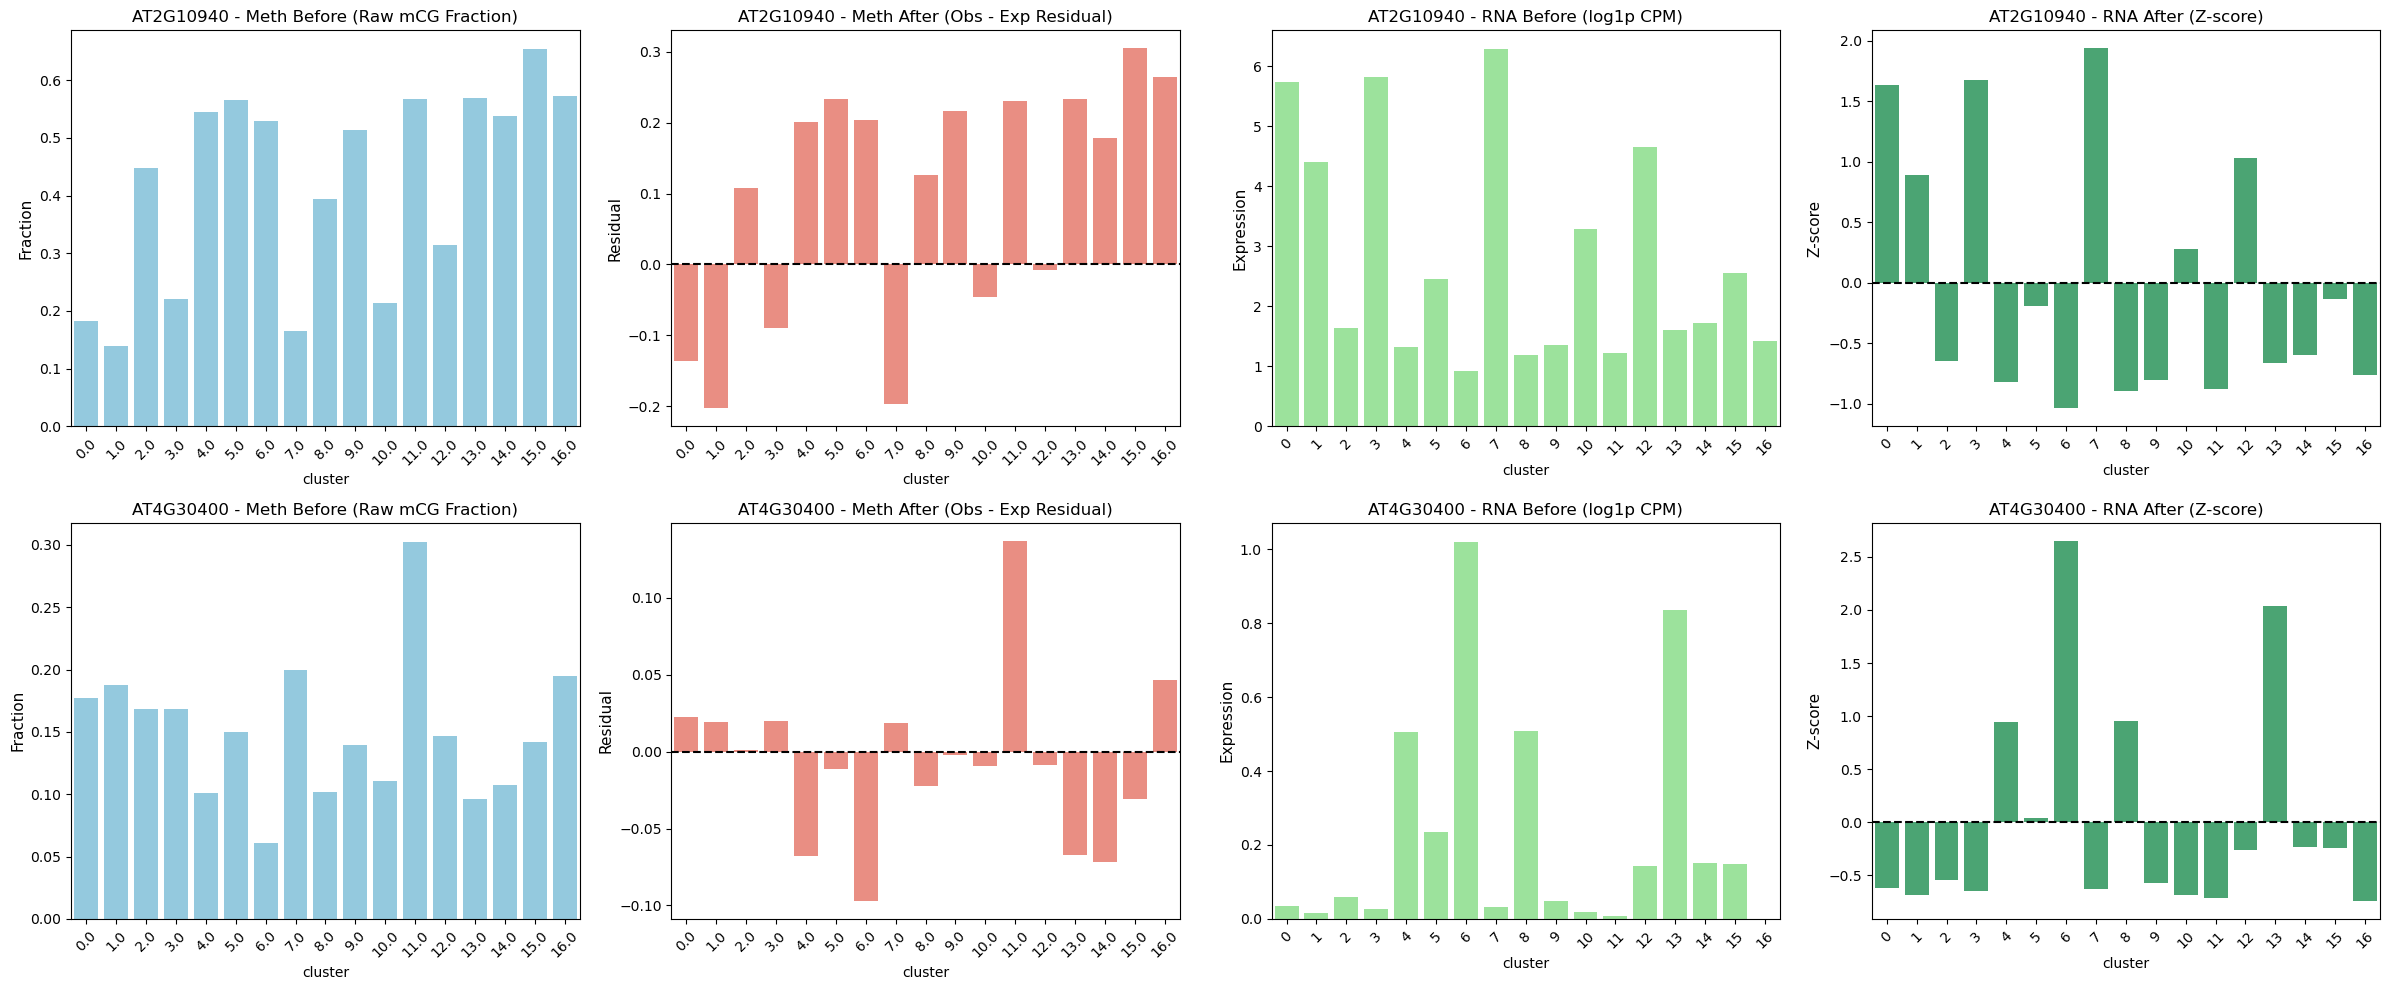

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import zscore

genes_to_check = ['AT2G10940', 'AT4G30400']

# Create a grid: 1 row per gene, 4 columns for the progression
fig, axes = plt.subplots(len(genes_to_check), 4, figsize=(24, 5 * len(genes_to_check)))

# Ensure axes is 2D even for a single gene
if len(genes_to_check) == 1:
    axes = [axes]

for i, gene in enumerate(genes_to_check):
    # Extract Methylation Data
    has_meth = gene in obs_p.index and gene in adj_meth_matrix.index
    if has_meth:
        meth_raw = obs_p.loc[gene]
        meth_adj = adj_meth_matrix.loc[gene]
        
    # Extract RNA Data
    has_rna = gene in cluster_rna_matrix.index
    if has_rna:
        rna_raw = cluster_rna_matrix.loc[gene]
        rna_z = pd.Series(zscore(rna_raw), index=rna_raw.index)

    # --- Panel 1: Methylation Before (Raw Fraction) ---
    ax1 = axes[i, 0]
    if has_meth:
        sns.barplot(x=meth_raw.index, y=meth_raw.values, ax=ax1, color='skyblue')
        ax1.set_title(f"{gene} - Meth Before (Raw mCG Fraction)", fontsize=12)
        ax1.set_ylabel("Fraction", fontsize=11)
    else:
        ax1.set_title(f"{gene} - Methylation Data Missing", fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    
    # --- Panel 2: Methylation After (Logit Residual) ---
    ax2 = axes[i, 1]
    if has_meth:
        sns.barplot(x=meth_adj.index, y=meth_adj.values, ax=ax2, color='salmon')
        ax2.set_title(f"{gene} - Meth After (Obs - Exp Residual)", fontsize=12)
        ax2.set_ylabel("Residual", fontsize=11)
        ax2.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax2.tick_params(axis='x', rotation=45)

    # --- Panel 3: RNA Before (log1p CPM) ---
    ax3 = axes[i, 2]
    if has_rna:
        sns.barplot(x=rna_raw.index, y=rna_raw.values, ax=ax3, color='lightgreen')
        ax3.set_title(f"{gene} - RNA Before (log1p CPM)", fontsize=12)
        ax3.set_ylabel("Expression", fontsize=11)
    else:
        ax3.set_title(f"{gene} - RNA Data Missing", fontsize=12)
    ax3.tick_params(axis='x', rotation=45)

    # --- Panel 4: RNA After (Z-score) ---
    ax4 = axes[i, 3]
    if has_rna:
        sns.barplot(x=rna_z.index, y=rna_z.values, ax=ax4, color='mediumseagreen')
        ax4.set_title(f"{gene} - RNA After (Z-score)", fontsize=12)
        ax4.set_ylabel("Z-score", fontsize=11)
        ax4.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

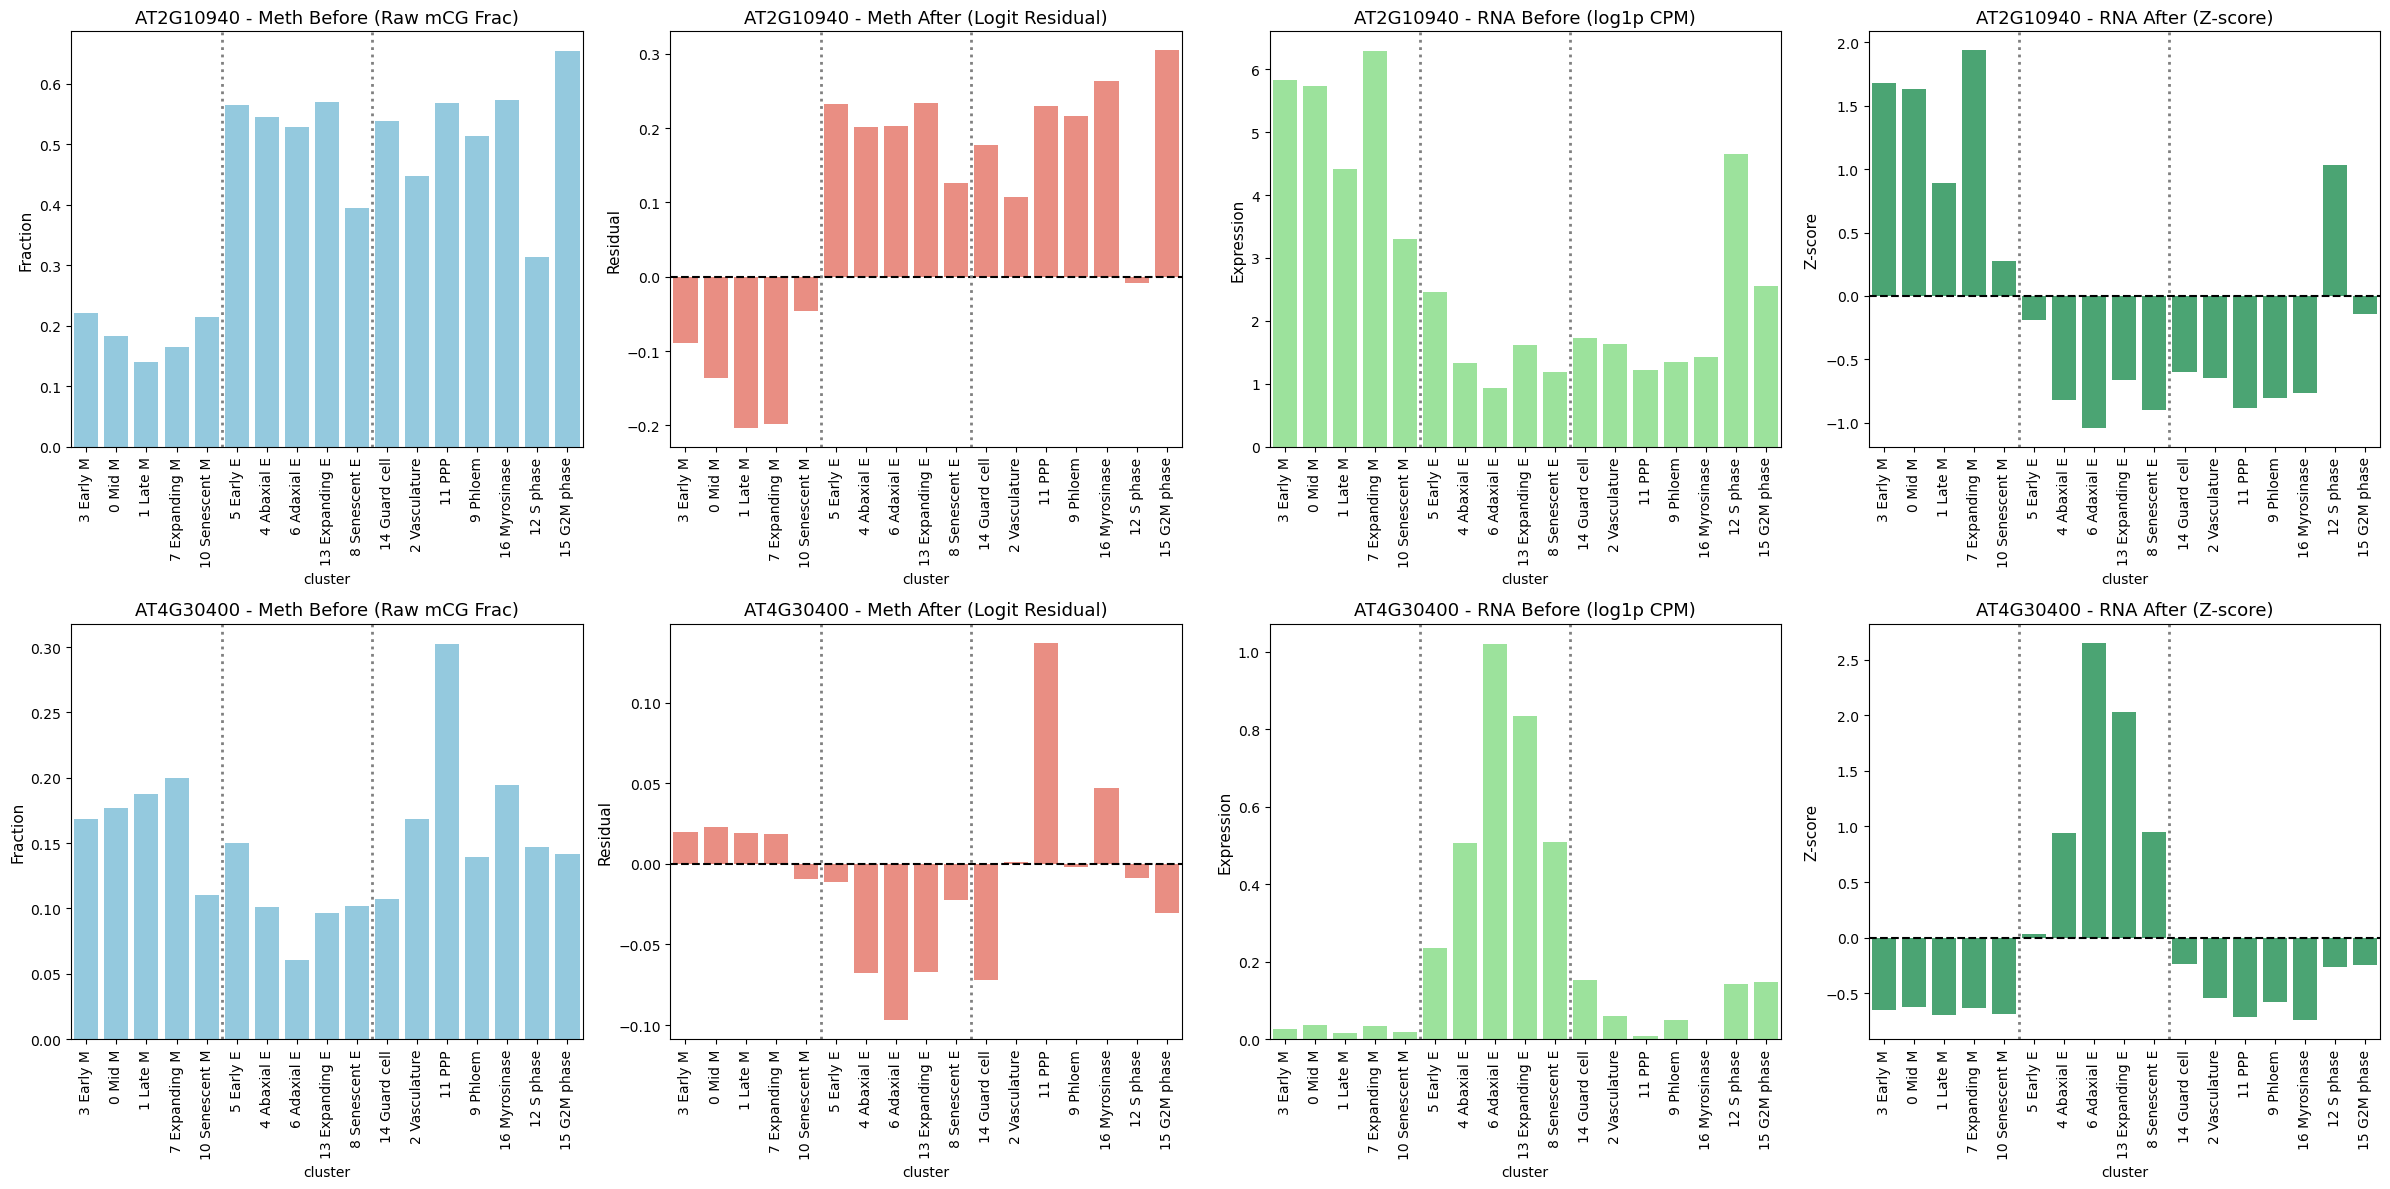

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import zscore

genes_to_check = ['AT2G10940', 'AT4G30400']

fig, axes = plt.subplots(len(genes_to_check), 4, figsize=(24, 6 * len(genes_to_check)))

if len(genes_to_check) == 1:
    axes = [axes]

for i, gene in enumerate(genes_to_check):
    # --- Data Extraction & Transformation ---
    has_meth = gene in obs_p.index and gene in adj_meth_matrix.index
    if has_meth:
        meth_raw = obs_p.loc[gene].rename(index=cluster_mapping)
        meth_adj = adj_meth_matrix.loc[gene].rename(index=cluster_mapping)
        valid_meth_order = [c for c in cluster_order if c in meth_raw.index]
        meth_raw = meth_raw.reindex(valid_meth_order)
        meth_adj = meth_adj.reindex(valid_meth_order)
        
    has_rna = gene in cluster_rna_matrix.index
    if has_rna:
        rna_raw = cluster_rna_matrix.loc[gene].rename(index=cluster_mapping)
        rna_z = pd.Series(zscore(rna_raw), index=rna_raw.index)
        valid_rna_order = [c for c in cluster_order if c in rna_raw.index]
        rna_raw = rna_raw.reindex(valid_rna_order)
        rna_z = rna_z.reindex(valid_rna_order)

    # --- Panel 1: Methylation Before ---
    ax1 = axes[i, 0]
    if has_meth:
        sns.barplot(x=meth_raw.index, y=meth_raw.values, ax=ax1, color='skyblue')
        ax1.set_title(f"{gene} - Meth Before (Raw mCG Frac)", fontsize=13)
        ax1.set_ylabel("Fraction", fontsize=11)
    else:
        ax1.set_title(f"{gene} - Meth Data Missing", fontsize=13)
    ax1.tick_params(axis='x', rotation=90)
    
    # --- Panel 2: Methylation After ---
    ax2 = axes[i, 1]
    if has_meth:
        sns.barplot(x=meth_adj.index, y=meth_adj.values, ax=ax2, color='salmon')
        ax2.set_title(f"{gene} - Meth After (Logit Residual)", fontsize=13)
        ax2.set_ylabel("Residual", fontsize=11)
        ax2.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax2.tick_params(axis='x', rotation=90)

    # --- Panel 3: RNA Before ---
    ax3 = axes[i, 2]
    if has_rna:
        sns.barplot(x=rna_raw.index, y=rna_raw.values, ax=ax3, color='lightgreen')
        ax3.set_title(f"{gene} - RNA Before (log1p CPM)", fontsize=13)
        ax3.set_ylabel("Expression", fontsize=11)
    else:
        ax3.set_title(f"{gene} - RNA Data Missing", fontsize=13)
    ax3.tick_params(axis='x', rotation=90)

    # --- Panel 4: RNA After ---
    ax4 = axes[i, 3]
    if has_rna:
        sns.barplot(x=rna_z.index, y=rna_z.values, ax=ax4, color='mediumseagreen')
        ax4.set_title(f"{gene} - RNA After (Z-score)", fontsize=13)
        ax4.set_ylabel("Z-score", fontsize=11)
        ax4.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax4.tick_params(axis='x', rotation=90)

    # Add vertical dividers to separate cell types visually
    for ax in [ax1, ax2, ax3, ax4]:
        ax.axvline(4.5, color='gray', linestyle=':', lw=2) # Divider after Mesophyll
        ax.axvline(9.5, color='gray', linestyle=':', lw=2) # Divider after Epidermis

plt.tight_layout()
plt.show()

# check AT2G10940

--- Stats for AT4G30400 ---
Rank: 2.0 out of 12742
Rho (Spearman): -0.8750
P-value: 4.2801e-06
FDR: 2.7269e-02

--- Top 5 Ranked Genes for Comparison ---
                rho       p_value       fdr
gene                                       
AT4G01130 -0.904180  6.362151e-07  0.008107
AT4G30400 -0.875000  4.280116e-06  0.027269
AT4G05025 -0.857496  1.084623e-05  0.042392
AT3G26290 -0.843137  2.132810e-05  0.042392
AT5G46295 -0.842754  2.169619e-05  0.042392




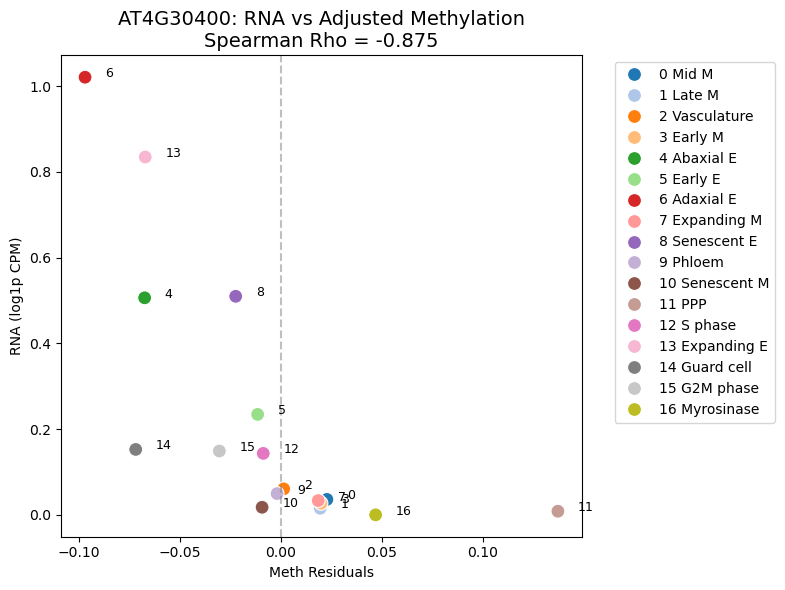

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

target_gene = 'AT4G30400'

# 1. Check where the gene ranks
stats_sorted = stats_df.sort_values('rho')
stats_sorted['rank'] = range(1, len(stats_sorted) + 1)

if target_gene in stats_sorted.index:
    target_stats = stats_sorted.loc[target_gene]
    print(f"--- Stats for {target_gene} ---")
    print(f"Rank: {target_stats['rank']} out of {len(stats_sorted)}")
    print(f"Rho (Spearman): {target_stats['rho']:.4f}")
    print(f"P-value: {target_stats['p_value']:.4e}")
    print(f"FDR: {target_stats['fdr']:.4e}\n")
else:
    print(f"{target_gene} not found in stats_df (failed coverage or variance filters).")

print("--- Top 5 Ranked Genes for Comparison ---")
print(stats_sorted[['rho', 'p_value', 'fdr']].head(5))
print("\n")

# 2. Visualize the exact Scatter of Ranks for the target gene
if target_gene in final_rna_df.index and target_gene in final_meth_df.index:
    rna_vals = final_rna_df.loc[target_gene]
    meth_vals = final_meth_df.loc[target_gene]
    
    # Create a dataframe for plotting
    plot_df = pd.DataFrame({
        'RNA (log1p CPM)': rna_vals,
        'Meth Residuals': meth_vals,
        'Cluster': [cluster_mapping.get(c, str(c)) for c in rna_vals.index]
    })
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(data=plot_df, x='Meth Residuals', y='RNA (log1p CPM)', 
                    s=100, hue='Cluster', palette='tab20', ax=ax)
    
    # Annotate points to see which clusters break the rank order
    for i, row in plot_df.iterrows():
        ax.text(row['Meth Residuals'] + 0.01, row['RNA (log1p CPM)'], 
                row['Cluster'].split(' ')[0], # Just print the cluster number to save space
                fontsize=9)
        
    ax.set_title(f"{target_gene}: RNA vs Adjusted Methylation\nSpearman Rho = {target_stats['rho']:.3f}", fontsize=14)
    plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
    
    # Place legend outside
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# WLS attempt

In [29]:
import statsmodels.api as sm
from scipy.stats import zscore

# Align genes across modalities
common_genes = cluster_rna_matrix.index.intersection(filtered_meth_df.index)
final_rna_df = cluster_rna_matrix.loc[common_genes]
final_meth_df = filtered_meth_df.loc[common_genes]

# We will use the total coverage (cluster_m) as our weights
final_weights_df = cluster_m.loc[common_genes]

correlations = []
p_values = []
valid_genes = []

for gene in common_genes:
    rna_vals = final_rna_df.loc[gene].values
    meth_vals = final_meth_df.loc[gene].values
    weight_vals = final_weights_df.loc[gene].values
    
    # Skip genes with zero variance in either modality
    if np.std(rna_vals) == 0 or np.std(meth_vals) == 0:
        continue
        
    # Standardize to make the WLS coefficient behave like a correlation coefficient (Rho)
    rna_z = zscore(rna_vals)
    meth_z = zscore(meth_vals)
    
    # Add constant for intercept
    X = sm.add_constant(meth_z)
    
    try:
        # Fit Weighted Least Squares
        # Endog (Y) = RNA, Exog (X) = Methylation
        wls_model = sm.WLS(endog=rna_z, exog=X, weights=weight_vals).fit()
        
        # Extract the slope coefficient (pseudo-rho) and its p-value
        # Index 1 is the slope for 'meth_z' (Index 0 is the constant)
        rho = wls_model.params[1] 
        p = wls_model.pvalues[1]
        
        valid_genes.append(gene)
        correlations.append(rho)
        p_values.append(p)
    except Exception:
        # Catch any convergence errors for extremely sparse genes
        continue

# Compile statistical results
stats_df = pd.DataFrame({
    'gene': valid_genes,
    'rho': correlations,
    'p_value': p_values
}).set_index('gene')

# Apply FDR correction
stats_df['fdr'] = multipletests(stats_df['p_value'], method='fdr_bh')[1]

print("Top 20 negatively correlated genes (WLS, Coverage-Weighted):")
print(stats_df.sort_values('rho').head(20))

Top 20 negatively correlated genes (WLS, Coverage-Weighted):
                rho   p_value       fdr
gene                                   
AT2G04790 -1.732238  0.000114  0.032653
AT2G07713 -1.663293  0.047919  0.496955
AT1G55370 -1.634012  0.000215  0.045561
AT5G35490 -1.449742  0.000016  0.008352
AT3G29639 -1.407684  0.003538  0.209529
AT2G04825 -1.384154  0.003283  0.206739
AT1G52240 -1.302113  0.001152  0.122335
AT3G21670 -1.298125  0.000027  0.011065
AT3G55735 -1.297038  0.000452  0.069419
AT3G26290 -1.294671  0.000006  0.004282
AT5G49740 -1.251251  0.000018  0.008440
AT2G05615 -1.246359  0.018173  0.376778
AT4G04330 -1.238686  0.014208  0.341467
AT3G29033 -1.235975  0.041621  0.471824
AT4G04265 -1.222466  0.010509  0.302969
AT5G23060 -1.201050  0.020242  0.387271
AT2G07764 -1.197692  0.272472  0.744871
AT5G57760 -1.196886  0.000578  0.081813
AT1G58290 -1.196723  0.000166  0.039083
AT4G38870 -1.191051  0.002114  0.173913


In [32]:
# Sort the WLS results by 'rho' (most negative/strongest inverse relationship at the top)
stats_sorted_wls = stats_df.sort_values('rho')

# Add a rank column (Rank 1 = most negative correlation)
stats_sorted_wls['rank'] = range(1, len(stats_sorted_wls) + 1)

target_gene = 'AT2G10940'

if target_gene in stats_sorted_wls.index:
    target_stats = stats_sorted_wls.loc[target_gene]
    print(f"--- WLS Stats for {target_gene} ---")
    print(f"Rank: {int(target_stats['rank'])} out of {len(stats_sorted_wls)}")
    print(f"Pseudo-Rho (WLS slope): {target_stats['rho']:.4f}")
    print(f"P-value: {target_stats['p_value']:.4e}")
    print(f"FDR: {target_stats['fdr']:.4e}")
else:
    print(f"{target_gene} not found in stats_df. It may have been filtered out due to zero variance.")

--- WLS Stats for AT2G10940 ---
Rank: 84 out of 12742
Pseudo-Rho (WLS slope): -0.9586
P-value: 1.0429e-06
FDR: 1.2081e-03


Plotting top 300 genes with the strongest negative WLS correlation.


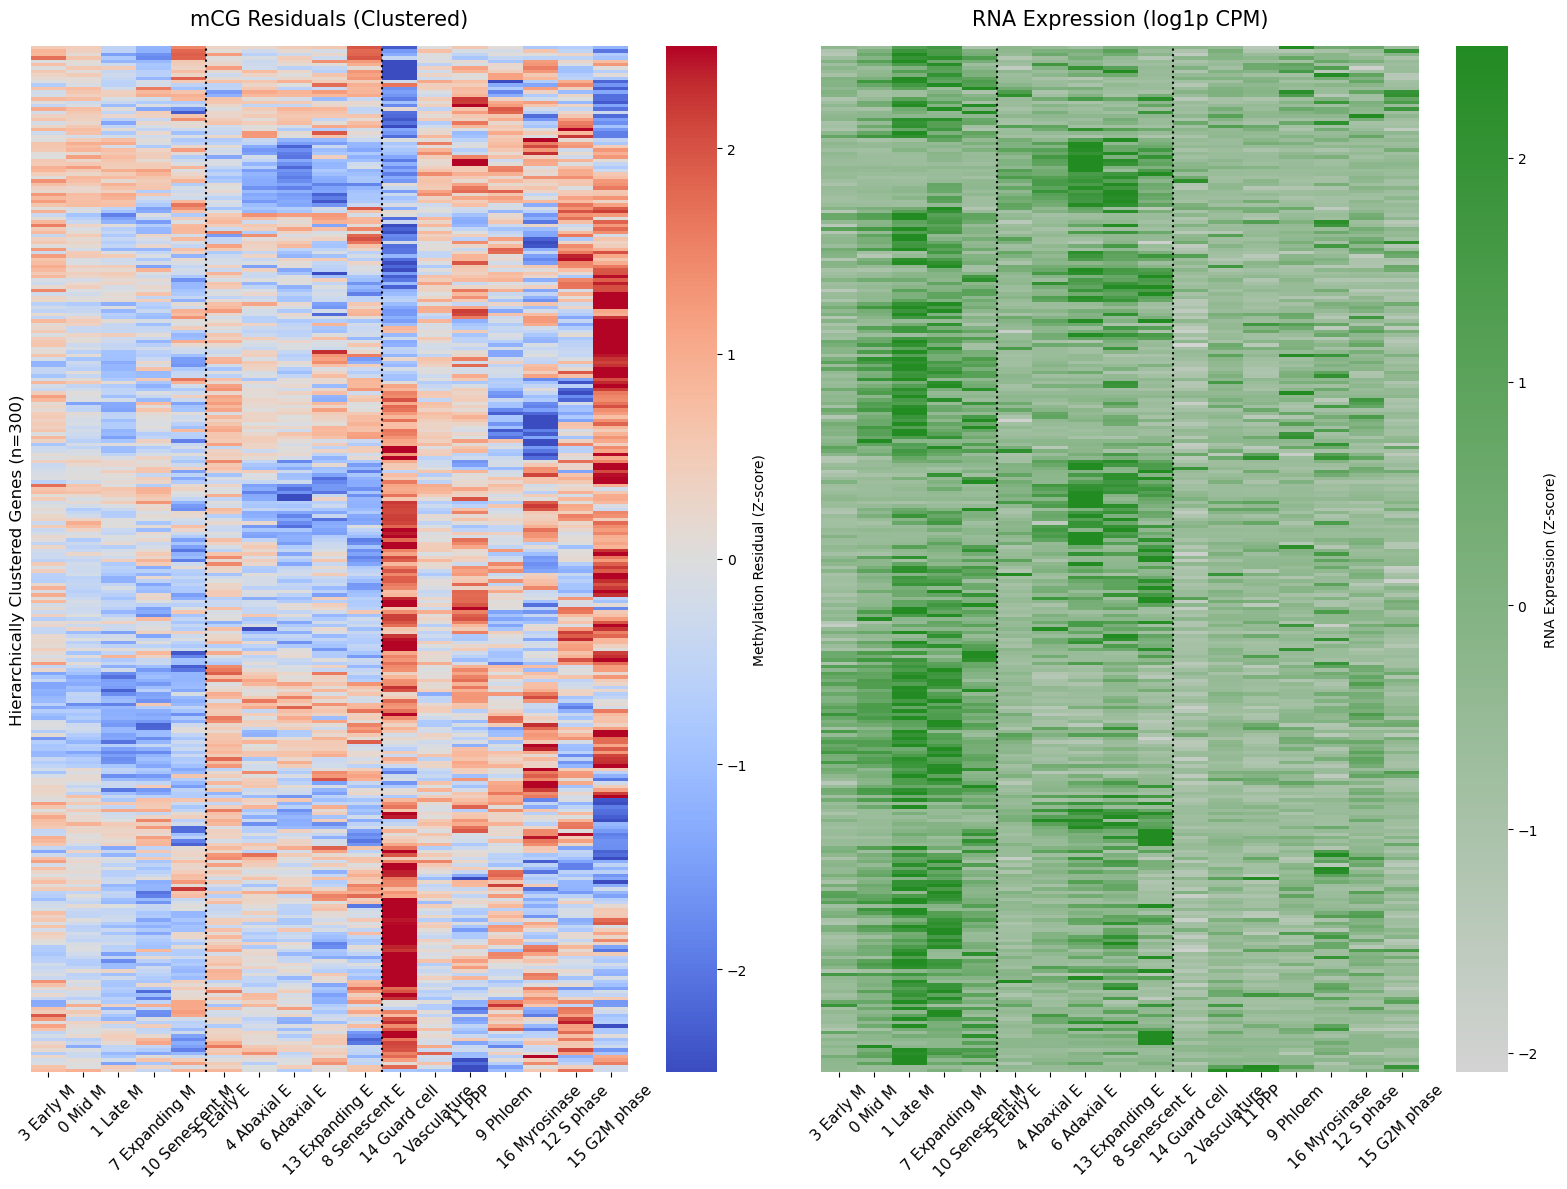

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import zscore
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp

# 1. Get the Top 300 genes from the WLS results
top_300_genes = stats_df.sort_values('rho').head(300).index
print(f"Plotting top {len(top_300_genes)} genes with the strongest negative WLS correlation.")

# 2. Data Preparation (Z-scoring)
def prepare_zscore(df, genes):
    subset = df.loc[genes]
    z = subset.apply(zscore, axis=1)
    return z.clip(lower=-2.5, upper=2.5)

vis_meth_z = prepare_zscore(final_meth_df, top_300_genes)
vis_rna_z = prepare_zscore(final_rna_df, top_300_genes)

# 3. Apply Custom Cluster Names and Column Ordering
vis_meth_sorted = vis_meth_z.rename(columns=cluster_mapping)
vis_rna_sorted = vis_rna_z.rename(columns=cluster_mapping)

valid_order = [c for c in cluster_order if c in vis_meth_sorted.columns]
vis_meth_sorted = vis_meth_sorted[valid_order]
vis_rna_sorted = vis_rna_sorted[valid_order]

# --- NEW: 4. Hierarchical Clustering on Genes (Rows) ---
# We cluster based on the methylation patterns to group similar regulatory states together
row_linkage = hc.linkage(sp.distance.pdist(vis_meth_sorted.values), method='ward')
row_order = hc.leaves_list(row_linkage)

# Extract the new clustered gene order
clustered_genes = vis_meth_sorted.index[row_order]

# Reorder the rows of both dataframes using this new clustered order
vis_meth_clustered = vis_meth_sorted.loc[clustered_genes]
vis_rna_clustered = vis_rna_sorted.loc[clustered_genes]

# 5. Create custom colormap for RNA (Grey for low, Forest Green for high)
rna_cmap = LinearSegmentedColormap.from_list("Grey_to_Green", ["lightgrey", "forestgreen"])

# 6. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 12), gridspec_kw={'width_ratios': [1, 1]})

# Methylation Heatmap (Coolwarm)
sns.heatmap(vis_meth_clustered, cmap="coolwarm", center=0, ax=ax1, 
            cbar_kws={'label': 'Methylation Residual (Z-score)'}, yticklabels=False)
ax1.set_title("mCG Residuals (Clustered)", fontsize=15, pad=15)
ax1.set_xlabel("")
ax1.set_ylabel(f"Hierarchically Clustered Genes (n={len(top_300_genes)})", fontsize=12)
ax1.tick_params(axis='x', rotation=45, labelsize=11)

# RNA Expression Heatmap (Grey to Green)
sns.heatmap(vis_rna_clustered, cmap=rna_cmap, ax=ax2, 
            cbar_kws={'label': 'RNA Expression (Z-score)'}, yticklabels=False)
ax2.set_title("RNA Expression (log1p CPM)", fontsize=15, pad=15)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.tick_params(axis='x', rotation=45, labelsize=11)

# Add visual dividers for Mesophyll and Epidermis groupings
for ax in [ax1, ax2]:
    ax.axvline(5, color='black', lw=1.5, linestyle=':')  # After Senescent M
    ax.axvline(10, color='black', lw=1.5, linestyle=':') # After Senescent E

plt.tight_layout()
plt.savefig("rna_meth_wls_top300_clustered_heatmap.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

# identify hypo

In [37]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

def identify_hypomethylated_clusters(gene_list, obs_p, adj_meth_matrix, cluster_m, 
                                     min_coverage=10, 
                                     residual_threshold=-0.15, 
                                     zscore_threshold=-1.5):
    """
    Identifies hypomethylated clusters for a given list of genes.
    
    Parameters:
    - gene_list: List of gene IDs to query.
    - obs_p: Raw observed methylation fraction matrix.
    - adj_meth_matrix: Residual matrix (Observed - Expected).
    - cluster_m: Matrix of total coverage (m) per cluster per gene.
    - min_coverage: Minimum total reads required in a cluster to evaluate it.
    - residual_threshold: The absolute drop required (e.g., -0.15 means observed is 15% lower than expected).
    - zscore_threshold: How far below the gene's own average the cluster must be (Z-score).
    """
    results = []
    
    # Filter for genes that actually exist in the computed matrices
    valid_genes = [g for g in gene_list if g in adj_meth_matrix.index]
    
    for gene in valid_genes:
        # Extract data for the single gene
        gene_obs = obs_p.loc[gene]
        gene_adj = adj_meth_matrix.loc[gene]
        gene_cov = cluster_m.loc[gene]
        
        # 1. Gene-level sanity check: The gene must be methylated somewhere to be "hypomethylated" elsewhere
        # If the highest raw methylation in any cluster is below 10%, it's just an unmethylated gene
        if gene_obs.max() < 0.10:
            continue
            
        # 2. Coverage filter: Mask out clusters with insufficient reads
        valid_clusters_mask = gene_cov >= min_coverage
        
        if valid_clusters_mask.sum() < 3:
            continue # Not enough valid clusters to compute a meaningful baseline
            
        valid_adj = gene_adj[valid_clusters_mask]
        
        # 3. Calculate Z-scores of the residuals across the valid clusters
        # This tells us which clusters are outliers in their demethylation
        adj_zscores = pd.Series(zscore(valid_adj), index=valid_adj.index)
        
        # 4. Identify the hypomethylated clusters
        # Must be highly negative in absolute terms AND a negative outlier relative to other clusters
        hypo_clusters = valid_adj[(valid_adj <= residual_threshold) & (adj_zscores <= zscore_threshold)].index.tolist()
        
        if hypo_clusters:
            for cluster in hypo_clusters:
                results.append({
                    'Gene': gene,
                    'Cluster': cluster,
                    'Raw_Fraction': gene_obs[cluster],
                    'Residual': valid_adj[cluster],
                    'Z_Score': adj_zscores[cluster],
                    'Coverage': gene_cov[cluster]
                })
                
    return pd.DataFrame(results).sort_values(by=['Gene', 'Residual'])

# --- Example Usage ---
# Assuming you have a list of genes of interest
my_gene_list = ['AT2G10940', 'AT4G30400'] # Replace with your actual list

hypo_results_df = identify_hypomethylated_clusters(
    gene_list=my_gene_list,
    obs_p=obs_p, 
    adj_meth_matrix=adj_meth_matrix, 
    cluster_m=cluster_m,
    min_coverage=15,           # Require at least 15 reads to trust the fraction
    residual_threshold=-0.15,  # Must drop at least 15% below the expected logit baseline
    zscore_threshold=-1.5      # Must be an outlier drop for this specific gene
)

print("Significantly Hypomethylated Clusters per Gene:")
print(hypo_results_df.to_string(index=False))

Significantly Hypomethylated Clusters per Gene:
     Gene  Cluster  Raw_Fraction  Residual   Z_Score  Coverage
AT2G10940      1.0      0.139416 -0.203205 -1.800050      6269
AT2G10940      7.0      0.165450 -0.197516 -1.765722      2055


In [36]:
# 1. Read the genes from the text file
with open('hazel_list.txt', 'r') as file:
    # .strip() removes spaces and \n characters, and we ignore empty lines
    my_gene_list = [line.strip() for line in file if line.strip()]

print(f"Successfully loaded {len(my_gene_list)} genes from hazel_list.txt.")

# 2. Run the identification function
hypo_results_df = identify_hypomethylated_clusters(
    gene_list=my_gene_list,
    obs_p=obs_p, 
    adj_meth_matrix=adj_meth_matrix, 
    cluster_m=cluster_m,
    min_coverage=15,           # Require at least 15 reads to trust the fraction
    residual_threshold=-0.15,  # Must drop at least 15% below the expected logit baseline
    zscore_threshold=-1.5      # Must be an outlier drop for this specific gene
)

# 3. View the results sorted by gene and how deep the hypomethylation goes
display(hypo_results_df.head(20))

# Optional: Save the results to a new CSV for your records
hypo_results_df.to_csv("hypomethylated_clusters_results.csv", index=False)
print("Saved detailed results to hypomethylated_clusters_results.csv")

Successfully loaded 1238 genes from hazel_list.txt.


,Gene,Cluster,Raw_Fraction,Residual,Z_Score,Coverage
0,AT1G11785,6.0,0.451977,-0.155360,-2.191084,531
1,AT1G28135,13.0,0.456044,-0.235933,-3.032451,182
2,AT1G29540,6.0,0.098077,-0.166049,-2.550087,1040
3,AT1G31935,14.0,0.326087,-0.166956,-2.123372,46
4,AT1G32225,10.0,0.295796,-0.158498,-1.503919,666
5,AT1G34860,16.0,0.634615,-0.157061,-2.208408,52
6,AT1G36005,11.0,0.411765,-0.168273,-1.926960,136
7,AT1G42080,16.0,0.345238,-0.199936,-2.496252,84
8,AT1G43040,8.0,0.311881,-0.200742,-1.773409,808
10,AT1G49230,11.0,0.170404,-0.210016,-2.126132,223


Saved detailed results to hypomethylated_clusters_results.csv


In [40]:
def identify_relative_lows(gene_list, obs_p, adj_meth_matrix, cluster_m, 
                           min_coverage=10, 
                           residual_threshold=-0.05,    # RELAXED: Only require a 5% drop
                           zscore_threshold=-1.0,       # RELAXED: Only 1 standard dev below mean
                           min_raw_max=0.05):           # RELAXED: Gene only needs 5% max methylation
    results = []
    valid_genes = [g for g in gene_list if g in adj_meth_matrix.index]
    
    for gene in valid_genes:
        gene_obs = obs_p.loc[gene]
        gene_adj = adj_meth_matrix.loc[gene]
        gene_cov = cluster_m.loc[gene]
        
        # Relaxed global unmethylated check
        if gene_obs.max() < min_raw_max:
            continue
            
        valid_clusters_mask = gene_cov >= min_coverage
        if valid_clusters_mask.sum() < 3:
            continue 
            
        valid_adj = gene_adj[valid_clusters_mask]
        adj_zscores = pd.Series(zscore(valid_adj), index=valid_adj.index)
        
        # Apply relaxed thresholds
        hypo_clusters = valid_adj[(valid_adj <= residual_threshold) & (adj_zscores <= zscore_threshold)].index.tolist()
        
        if hypo_clusters:
            for cluster in hypo_clusters:
                results.append({
                    'Gene': gene,
                    'Cluster': cluster,
                    'Raw_Fraction': gene_obs[cluster],
                    'Residual': valid_adj[cluster],
                    'Z_Score': adj_zscores[cluster],
                    'Coverage': gene_cov[cluster]
                })
                
    if not results:
        return pd.DataFrame()
    return pd.DataFrame(results).sort_values(by=['Gene', 'Residual'])

# --- Run with Relaxed Parameters for AT4G30400 ---
relaxed_results = identify_relative_lows(
    gene_list=['AT4G30400'],
    obs_p=obs_p, 
    adj_meth_matrix=adj_meth_matrix, 
    cluster_m=cluster_m,
    residual_threshold=-0.03,  # Just a 3% absolute drop required
    zscore_threshold=-1.0,     # 1 standard deviation below its own mean
    min_raw_max=0.00           # Turn off the "must be methylated somewhere" filter completely
)

display(relaxed_results)

,Gene,Cluster,Raw_Fraction,Residual,Z_Score,Coverage
1,AT4G30400,6.0,0.060750,-0.097046,-1.705512,2535
3,AT4G30400,14.0,0.107362,-0.071955,-1.229108,326
0,AT4G30400,4.0,0.100870,-0.067541,-1.145306,3906
2,AT4G30400,13.0,0.096386,-0.067230,-1.139404,830
